## Evaluation of different (vectorizer, model) pairs on 2 datasets

In [2]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from rital_nlp_project.common.utils import load_clean_data
from rital_nlp_project.common.notebook_utils import init_notebook
from rital_nlp_project.common.models.models_eval import eval_pipeline_movies, eval_pipeline_presidents, build_experiments, eval_experiments

import gensim.downloader as api
from gensim.models.fasttext import load_facebook_model

init_notebook()

### Movies

In [3]:
from rital_nlp_project.movies.models_config import word2vec_model, fasttext_model

texts_movies, classes_movies = load_clean_data("../Dataset/clean/movies_clean.parquet")
w2v_model = api.load(word2vec_model)
#ft_model = load_facebook_model(f"../models/{fasttext_model}")


In [4]:
experiments = build_experiments("movies", models={"word2vec":w2v_model})
#experiments = build_experiments(models={"word2vec":w2v_model, "fasttext":ft_model})

In [ ]:
evals = eval_experiments(experiments, texts_movies, classes_movies, eval_pipeline_fn=eval_pipeline_movies, cv=False, split=True)

Pipeline(steps=[('vect',
                 TfidfVectorizer(analyzer='char', max_features=10000,
                                 use_idf=False)),
                ('clf', MultinomialNB())])


/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv-313/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Pipeline(steps=[('vect',
                 TfidfVectorizer(analyzer='char', max_features=10000,
                                 use_idf=False)),
                ('clf', LogisticRegression())])
Pipeline(steps=[('vect',
                 TfidfVectorizer(analyzer='char', max_features=10000,
                                 use_idf=False)),
                ('clf', LinearSVC())])
Pipeline(steps=[('vect',
                 TfidfVectorizer(analyzer='char_wb', max_features=10000,
                                 ngram_range=(4, 4), use_idf=False)),
                ('clf', MultinomialNB())])
Pipeline(steps=[('vect',
                 TfidfVectorizer(analyzer='char_wb', max_features=10000,
                                 ngram_range=(4, 4), use_idf=False)),
                ('clf', LogisticRegression())])
Pipeline(steps=[('vect',
                 TfidfVectorizer(analyzer='char_wb', max_features=10000,
                                 ngram_range=(4, 4), use_idf=False)),
                ('clf', Line

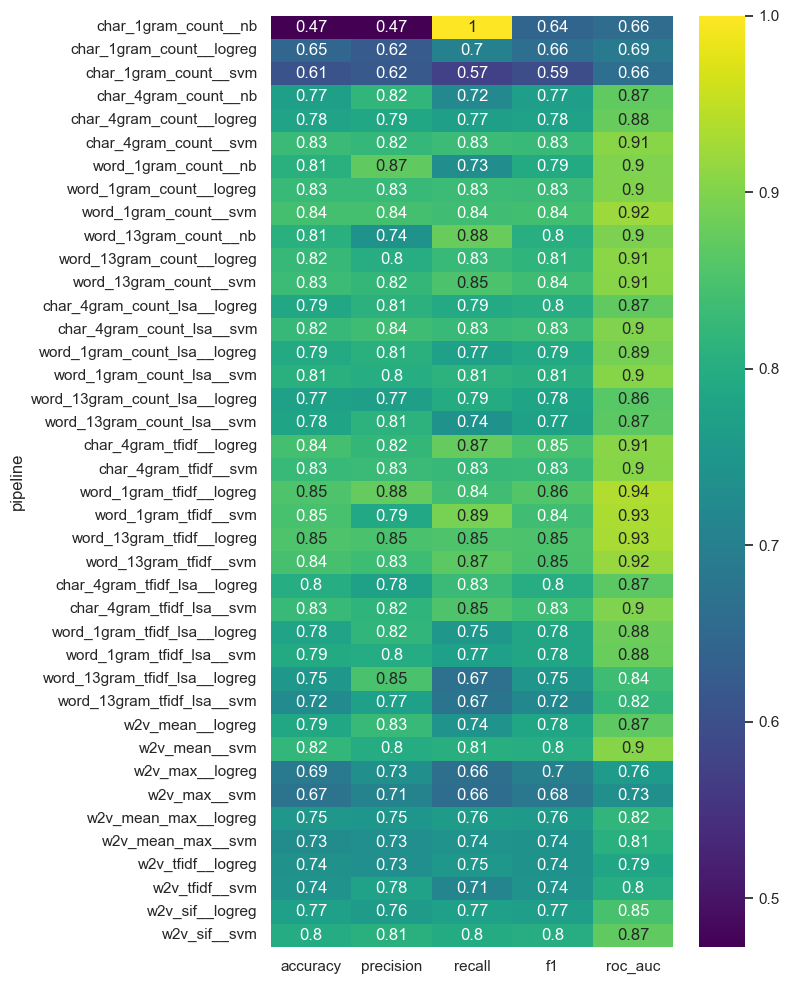

In [ ]:
plt.figure(figsize=(8, 10))
cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
sns.heatmap(evals.set_index("pipeline")[cols], annot=True, cmap="viridis")
plt.title("Train/test split")
plt.tight_layout()

In [ ]:
# plt.figure(figsize=(8, 10))
# cols = ['cv_accuracy', 'cv_precision', 'cv_recall', 'cv_f1', 'cv_roc_auc']
# sns.heatmap(evals.set_index("pipeline")[cols], annot=True, cmap="viridis")
# plt.title("Cross-validation (5-fold)")
# plt.tight_layout()

### Presidents

In [3]:
from rital_nlp_project.presidents.models_config import fasttext_model

texts_pres, classes_pres = load_clean_data("../Dataset/clean/presidents_clean.parquet")
#ft_model = load_facebook_model(f"../models/{fasttext_model}")

In [4]:
#experiments = build_experiments(models={"fasttext":ft_model})
experiments = build_experiments("presidents")

In [11]:
evals = eval_experiments(experiments, texts_pres, classes_pres, eval_pipeline_fn=eval_pipeline_presidents, cv=True, split=True)

Pipeline(steps=[('vect',
                 TfidfVectorizer(analyzer='char', max_features=10000,
                                 use_idf=False)),
                ('clf', MultinomialNB())])
Pipeline(steps=[('vect',
                 TfidfVectorizer(analyzer='char', max_features=10000,
                                 use_idf=False)),
                ('clf', LogisticRegression())])
Pipeline(steps=[('vect',
                 TfidfVectorizer(analyzer='char', max_features=10000,
                                 use_idf=False)),
                ('clf', LinearSVC())])
Pipeline(steps=[('vect',
                 TfidfVectorizer(analyzer='char', max_features=10000,
                                 use_idf=False)),
                ('clf',
                 SmoothedProbaClassifier(base_estimator=MultinomialNB(),
                                         sigma=1))])
Pipeline(steps=[('vect',
                 TfidfVectorizer(analyzer='char_wb', max_features=10000,
                                 ngram_ran

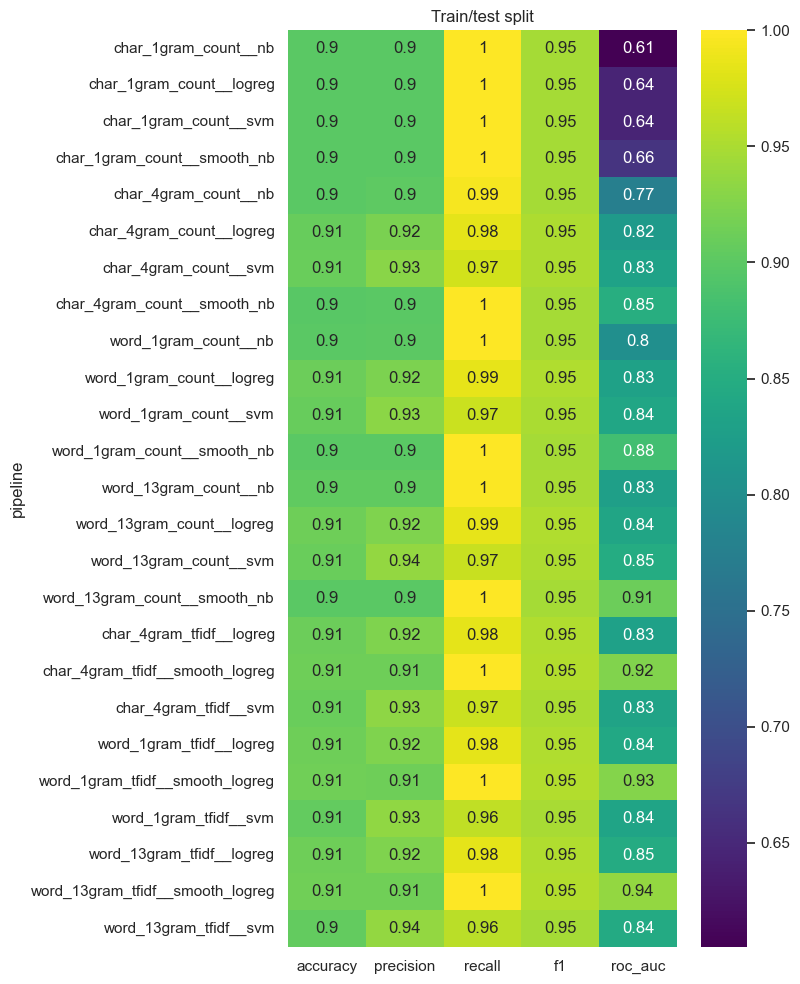

In [12]:
plt.figure(figsize=(8, 10))
cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
sns.heatmap(evals.set_index("pipeline")[cols], annot=True, cmap="viridis")
plt.title("Train/test split")
plt.tight_layout()

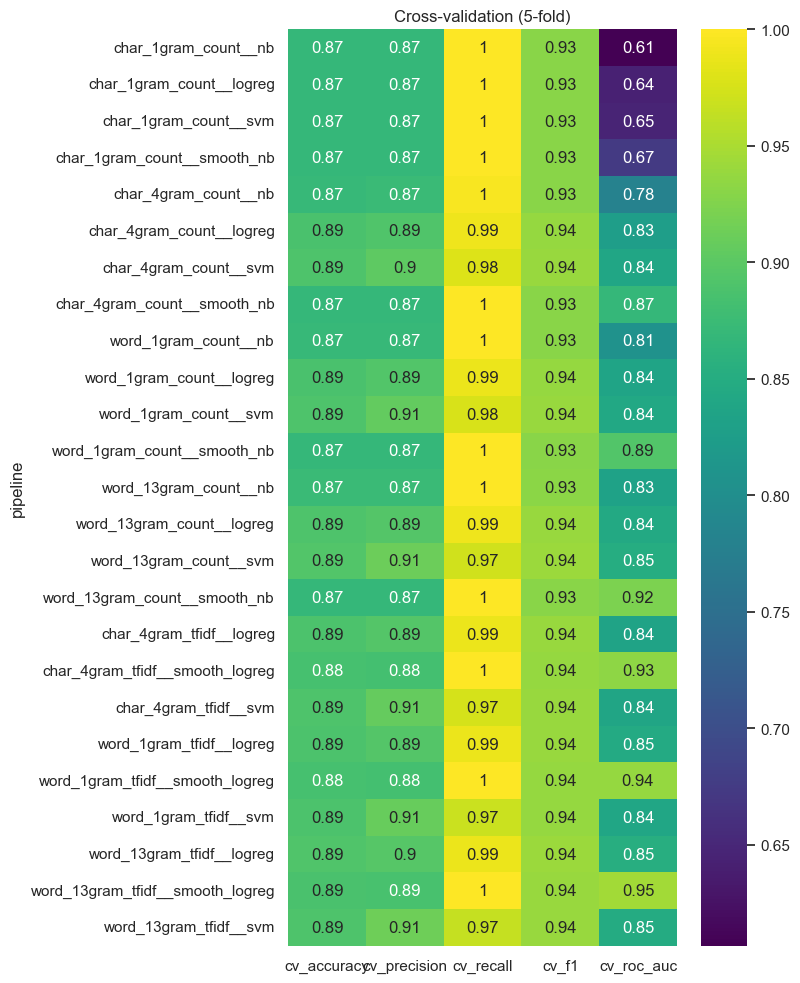

In [14]:
plt.figure(figsize=(8, 10))
cols = ['cv_accuracy', 'cv_precision', 'cv_recall', 'cv_f1', 'cv_roc_auc']
sns.heatmap(evals.set_index("pipeline")[cols], annot=True, cmap="viridis")
plt.title("Cross-validation (5-fold)")
plt.tight_layout()